<a href="https://colab.research.google.com/github/sharvarimhaske/sharvari_mhaske-data-frames_project/blob/main/19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving insurance (1).csv to insurance (1).csv


In [4]:
df = pd.read_csv("insurance (1).csv")

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [7]:
df.shape

(1338, 7)

In [8]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [9]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [11]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [12]:
(df.isnull().sum()/len(df))*100

,0
age,0.0
sex,0.0
bmi,0.0
children,0.0
smoker,0.0
region,0.0
charges,0.0


In [13]:
df.fillna(df.median(numeric_only=True), inplace=True)

for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_1385/3213490745.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [14]:
df.duplicated().sum()

np.int64(1)

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [18]:
print("Minimum:",df["charges"].min())
print("Maximum:",df["charges"].max())
print("Mean:",df["charges"].mean())
print("Median:",df["charges"].median())

Minimum: 1121.8739
Maximum: 63770.42801
Mean: 13279.121486655948
Median: 9386.1613


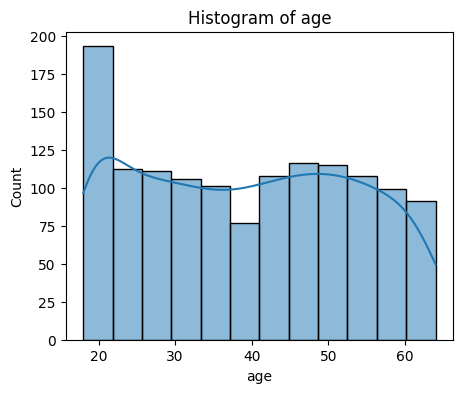

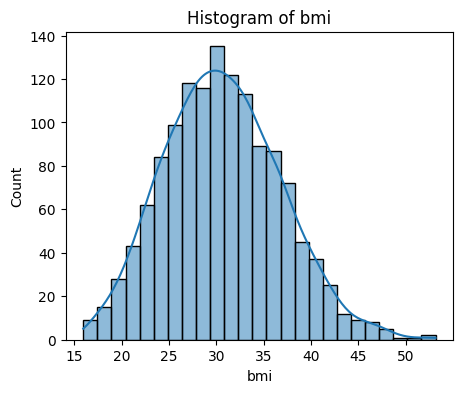

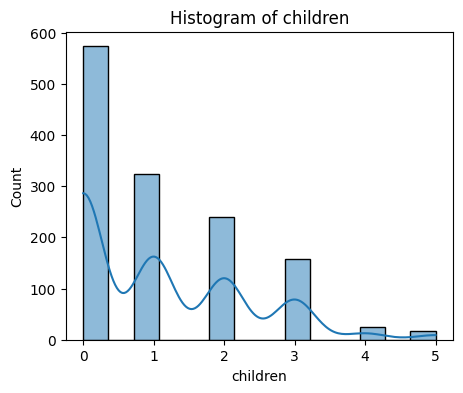

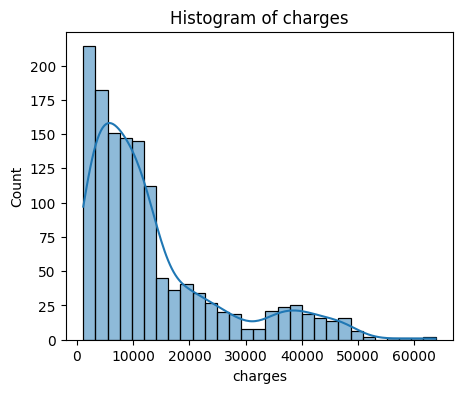

In [19]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(5,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.show()

In [20]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['sex', 'smoker', 'region'], dtype='object')

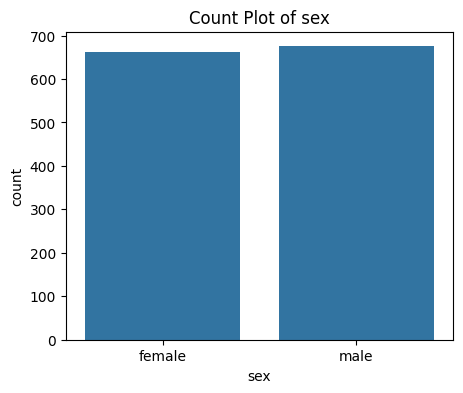

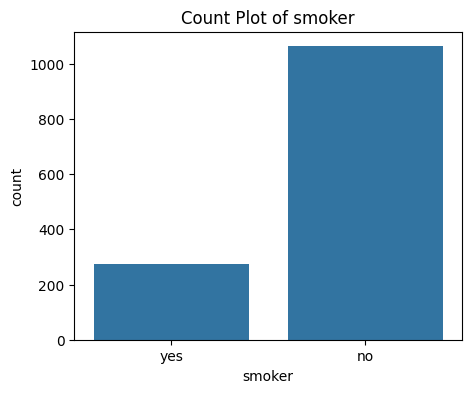

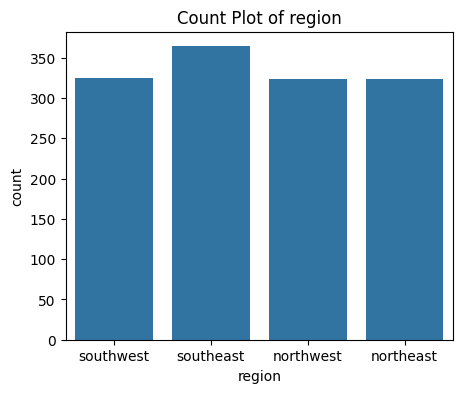

In [21]:
for col in cat_cols:
    plt.figure(figsize=(5,4))
    sns.countplot(x=df[col])
    plt.title(f'Count Plot of {col}')
    plt.show()

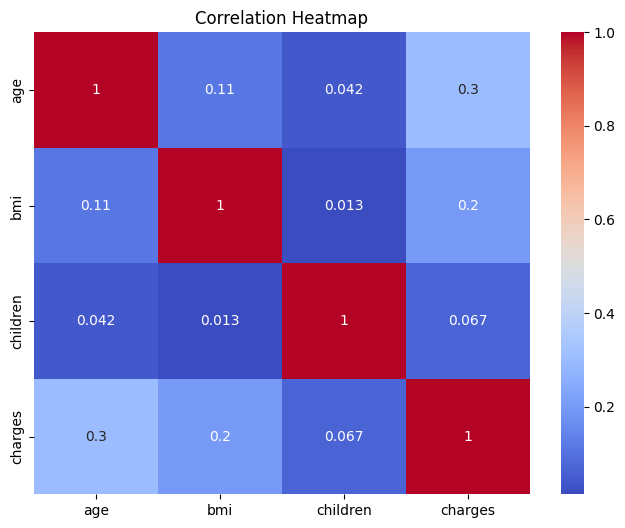

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [23]:
df.corr(numeric_only=True)["charges"].sort_values(ascending=False)

,charges
charges,1.000000
age,0.298308
bmi,0.198401
children,0.067389


In [24]:
X = df.drop("charges", axis=1)

In [25]:
y = df["charges"]

In [26]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [28]:
y.head()

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [29]:
df[['sex','smoker','region']].head()

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest


In [30]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [31]:
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [32]:
print(df[['sex','region']].head())

      sex     region
0  female  southwest
1    male  southeast
2    male  southeast
3    male  northwest
4    male  northwest


In [33]:
print(df_encoded.filter(regex='sex|region').head())

   sex_male  region_northwest  region_southeast  region_southwest
0     False             False             False              True
1      True             False              True             False
2      True             False              True             False
3      True              True             False             False
4      True              True             False             False


In [34]:
from sklearn.preprocessing import StandardScaler

In [35]:
X = df_encoded.drop("charges", axis=1)

In [36]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [37]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [38]:
X_scaled.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,-1.440418,-0.453160,-0.909234,-1.009771,1.969660,-0.565546,-0.611638,1.764609
1,-1.511647,0.509422,-0.079442,0.990324,-0.507702,-0.565546,1.634955,-0.566698
2,-0.799350,0.383155,1.580143,0.990324,-0.507702,-0.565546,1.634955,-0.566698
3,-0.443201,-1.305052,-0.909234,0.990324,-0.507702,1.768203,-0.611638,-0.566698
4,-0.514431,-0.292456,-0.909234,0.990324,-0.507702,1.768203,-0.611638,-0.566698
